In [2]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


☝ i have linked my drive and using the dataset from drive
--- refer this link for how to connect https://www.youtube.com/watch?v=Gvwuyx_F-28


In [2]:
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt
from IPython.display import HTML

In [3]:
BATCH_SIZE = 32
IMAGE_SIZE = 640
CHANNELS=3
EPOCHS=1

In [4]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/drive/MyDrive/fishDataSet/final dataset fish",
    seed=123,
    shuffle=True,
    image_size=(IMAGE_SIZE,IMAGE_SIZE),
    batch_size=BATCH_SIZE
)

Found 24287 files belonging to 82 classes.


what does this ☝ line do ?

*   tf.keras.preprocessing.image_dataset_from_directory -> loades all the images from folder
just visit this link for refernce you will come to know each word uses
 https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/image_dataset_from_directory

shuffle=True -> randomly shuffles


---


82 classes are nothing but 82 folders or types of fishes

In [5]:
class_names = dataset.class_names
class_names

['Bangus',
 'Big Head Carp',
 'Black Pomfret',
 'Black Sea Sprat',
 'Black Snapper',
 'Black Spotted Barb',
 'Black-winged hatchetfish',
 'Bristlenose_catfish',
 'Catfish',
 'Catla',
 'Climbing Perch',
 'CommonCarp',
 'Electric blue cichild',
 'Electric_fish',
 'Flowerhorn cichlid',
 'Fourfinger Threadfin',
 'Freshwater Eel',
 'Gilt Head Bream',
 'Gilt-Head Bream',
 'Glass Perchlet',
 'Goby',
 'Gold',
 'Gold Fish',
 'Gourami',
 'Grass Carp',
 'Green Spotted Puffer',
 'Guppy',
 'Horse Mackerel',
 'Indian Carp',
 'Indo-Pacific Tarpon',
 'Jaguar Gapote',
 'Janitor Fish',
 'Knifefish',
 'Long-Snouted Pipefish',
 'Mackerel',
 'Mori',
 'Mosquito Fish',
 'Mudfish',
 'Mullet',
 'Ocellate river stingray',
 'Oscar Fish',
 'Pangasius',
 'Paradise Fish',
 'Perch',
 'Pink Perch',
 'Powder_blue_fish',
 'Prawn',
 'Red Mullet',
 'Red Sea Bream',
 'Red_tail_black_shark',
 'Rohu',
 'Scat Fish',
 'Sea Bass',
 'Sea Horse Fish',
 'Shrimp',
 'Silver Barb',
 'Silver Carp',
 'Silver Perch',
 'SilverCarp',
 'S

In [9]:
len(dataset)

759

what does 759 refer here ?

---


it means the total of batches

*   1 batch has 32
*  759 batch has 32*759=24288 which is our total images





In [11]:
for image_batch, labels_batch in dataset.take(1):
    print(image_batch.shape)
    print(labels_batch.numpy())

(32, 640, 640, 3)
[52 48 58  6 61 47  2 52 44 44 47 53 47 50 34 54 44 65 65 74 54  3 54 52
 18 64 58 46  3 11 64  2]


(32, 640, 640, 3) -> 32 is batch size , 640 is image size , 3 is RGB (refer link to know RGB)

---

[52 48 58  6 61 47  2 52 44 44 47 53 47 50 34 54 44 65 65 74 54  3 54 52
 18 64 58 46  3 11 64  2] -> ramonly selected images from all the class

---
values lies between 0 to 82 (total no of classes)


**Visualize some of the images from our dataset**

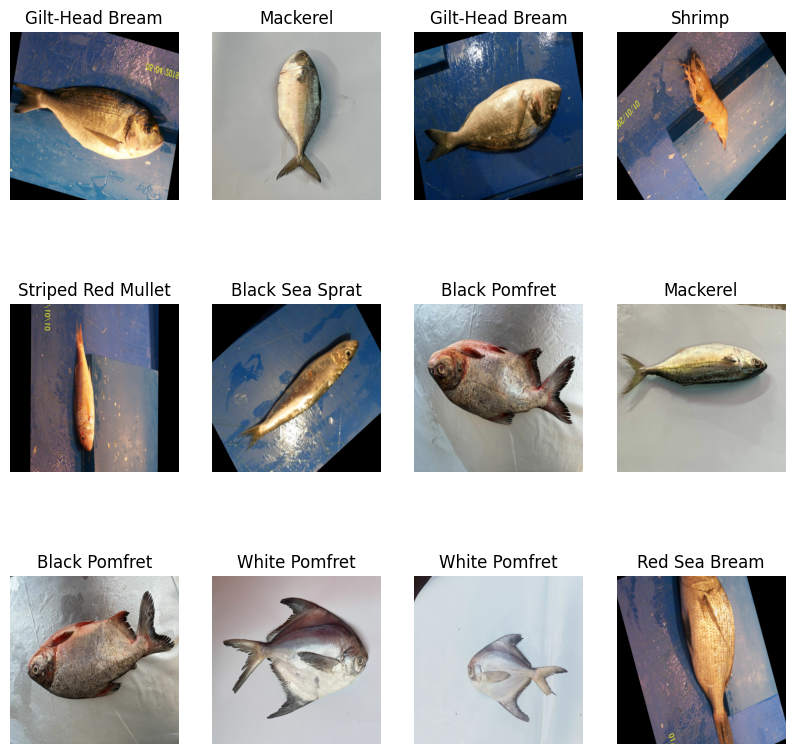

In [12]:
plt.figure(figsize=(10, 10))
for image_batch, labels_batch in dataset.take(1):
    for i in range(12):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.title(class_names[labels_batch[i]])
        plt.axis("off")

i have just visualized only 12 images , you can increase the values and see

**real part begins now **

80% -> for training
10%-> validation
10% -> testing



---



*   Training: Dataset to be used while training
*  Validation: Dataset to be tested against while training
*   
Test: Dataset to be tested against after we trained a model






In [13]:
train_size = 0.8
len(dataset)*train_size

607.2

80% for train

*  what is the total dataset(batch) for train ?
* dataset*80%









In [14]:
train_ds = dataset.take(607)
len(train_ds)

607

In [15]:
test_ds = dataset.skip(607)
len(test_ds)

152

ds.take -> we will take 607 for our model to train

---

ds.skip -> (total-skip(607) )left over dataset will be used for test and train

In [16]:
val_size=0.1
len(dataset)*val_size

75.9

In [17]:
val_ds = test_ds.take(75)
len(val_ds)

75

In [18]:
test_ds = test_ds.skip(75)
len(test_ds)

77

above what i have done is ,
done by manually , bellow i am using a python fuction that does the work for me


In [6]:
def get_dataset_partitions_tf(ds, train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True, shuffle_size=10000):
    assert (train_split + test_split + val_split) == 1

    ds_size = len(ds)

    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=12)

    train_size = int(train_split * ds_size)
    val_size = int(val_split * ds_size)

    train_ds = ds.take(train_size)
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size)

    return train_ds, val_ds, test_ds

In [7]:
train_ds, val_ds, test_ds = get_dataset_partitions_tf(dataset)

In [22]:
len(train_ds)


607

In [23]:
len(val_ds)

75

In [24]:
len(test_ds)

77

the manual way and the fuction way , values matches with each other

Cache, Shuffle, and Prefetch the Dataset

In [8]:
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

In [9]:
resize_and_rescale = tf.keras.Sequential([
    layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),
    layers.Rescaling(1./640),
])

☝ y i am resize and rescaleing it once again ?

---

beause i have seen some images that has width and height 640 , what if some has less or more than 640 , it will distrubt the model so i am doing this step

In [10]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
])

y i am doing data argumntaion
, it will make better , i am doing only light one just fliping it

---

types of data argumentation ->

flip, rotation, zoom, brightness change, etc





**Applying Data Augmentation to Train Dataset**

In [11]:
train_ds = train_ds.map(
    lambda x, y: (data_augmentation(x, training=True), y)
).prefetch(buffer_size=tf.data.AUTOTUNE)

now i am using CNN its a popular one model architeture

In [13]:
input_shape = (BATCH_SIZE, IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
n_classes = 3

model = models.Sequential([
    resize_and_rescale,
    layers.Conv2D(32, kernel_size = (3,3), activation='relu', input_shape=input_shape),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64,  kernel_size = (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64,  kernel_size = (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(n_classes, activation='softmax'),
])

model.build(input_shape=input_shape)

In [14]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (32, 640, 640, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (32, 638, 638, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (32, 319, 319, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (32, 317, 317, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (32, 158, 158, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (32, 156, 156, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (32, 78, 78, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (32, 76, 76, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (32, 38, 38, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (32, 36, 36, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (32, 18, 18, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (32, 16, 16, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (32, 8, 8, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (32, 4096)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (32, 64)               │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (32, 3)                │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 429,507 (1.64 MB)

 Trainable params: 429,507 (1.64 MB)

 Non-trainable params: 0 (0.00 B)

**Compiling the Model**

In [15]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_ds,
    batch_size=BATCH_SIZE,
    validation_data=val_ds,
    verbose=1,
    epochs=1,
)

drawing graphs

In [ ]:
history.history.keys()

In [ ]:
history.history['loss'][:5] # show loss for first 5 epochs

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

In [ ]:
plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(range(EPOCHS), acc, label='Training Accuracy')
plt.plot(range(EPOCHS), val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(range(EPOCHS), loss, label='Training Loss')
plt.plot(range(EPOCHS), val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

run the prediction model, sample runing

In [ ]:
import numpy as np
for images_batch, labels_batch in test_ds.take(1):

    first_image = images_batch[0].numpy().astype('uint8')
    first_label = labels_batch[0].numpy()

    print("first image to predict")
    plt.imshow(first_image)
    print("actual label:",class_names[first_label])

    batch_prediction = model.predict(images_batch)
    print("predicted label:",class_names[np.argmax(batch_prediction[0])])

function for **inference**

In [ ]:
def predict(model, img):
    img_array = tf.keras.preprocessing.image.img_to_array(images[i].numpy())
    img_array = tf.expand_dims(img_array, 0)

    predictions = model.predict(img_array)

    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = round(100 * (np.max(predictions[0])), 2)
    return predicted_class, confidence

runing inference on few sample images

In [ ]:
plt.figure(figsize=(15, 15))
for images, labels in test_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))

        predicted_class, confidence = predict(model, images[i].numpy())
        actual_class = class_names[labels[i]]

        plt.title(f"Actual: {actual_class},\n Predicted: {predicted_class}.\n Confidence: {confidence}%")

        plt.axis("off")

saving the model

In [ ]:
model.save("finalFishModel.h5")